### 🤖 Guía de Asistencia con IA: IA como Copiloto de Programación

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Explicación de código**: Si encuentras una función o línea que no comprendes, pregúntale a la IA: *'Explica qué hace esta función línea por línea en Python: [pega tu código]'*.
- **Corrección de errores**: Si tienes un error al ejecutar, copia el error completo y pregúntale: *'¿Por qué este código genera este error y cómo lo soluciono? [pega tu código y error]'*.
- **Optimización**: Pregunta: *'¿Cómo puedo escribir este código de forma más eficiente y limpia?'*.


# Programa Ingenias+ Data Science




## Analisis Exploratorio de un Dataset

Esta notebook les permitiria ejercitar los conceptos de Pandas 🐼  y Análisis exploratorio de datos 📊 que aprendimos hasta ahora. Vamos a trabajar con un dataset que contiene datos relativos a [clientes de un centro comercial](https://www.kaggle.com/akram24/mall-customers). En el Drive esta descargado el archivo. Si tenes inconvenientes o  ese archivo no funciona podes descargarlo directamente de la página web.

### 🔬 Comenzando el proyecto 🎉

Es tu primer dia como Data Scientist. Tu primer proyecto consiste en hacer un análisis de datos sobre clientes de un centro comercial para luego hacer una predicción de ventas o un analisis de cluster. Antes que nada, debes inspeccionar y visualizar tu dataset para saber con que datos estas trabajando.

Como mencionamos durante la clase, una de las primeras cosas que debe realizar un Data Scientist al iniciar un nuevo proyecto es conocer el dataset con el cual va a trabajar. Este paso se conoce como _"Analisis exploratorio de los datos"_.

Además de obtener que tipo de datos contiene el dataset, estadistica descriptiva, detectar problemas como valores faltantes, establecer que tipo de relación existe entre las distintas variables, también debemos visualizar los datos. Este análisis nos permitira hacernos preguntas que puedan ser contestadas con el dataset como así plantear estrategias para poder resolver problemas presentes en él.

#### IMPORTA LAS LIBRERIAS NECESARIAS

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
data = pd.read_csv('C:/Users/gn_d4/Documents/GERMÁN/DATA SCIENCE/DATA SCIENCE/NOTEBOOKS/NOTEBOOKS 2026/clientes_mall.csv')

**_Lee los datos que se encuentran en el archivo `clientes_mall.csv`. Guardalos en un DataFrame._**

In [9]:
data.index

RangeIndex(start=0, stop=200, step=1)

In [10]:
data.columns

Index(['Unnamed: 0', 'CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

#### INSPECCIONA LOS DATOS

Primero obtene una visión general del dataset:


🤔 &nbsp; **_¿Como se ven las primeras 5 filas? ¿Cuantas filas y columnas posee? ¿Que tipos de datos contiene cada una de las columnas?_**

In [11]:
data.head()

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0


In [12]:
data.shape

(200, 6)

In [13]:
data.dtypes

Unnamed: 0                  int64
CustomerID                float64
Genre                         str
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

In [14]:
data

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
...,...,...,...,...,...,...
195,195,196.0,NaN,35.0,120.0,79.0
196,196,197.0,Female,45.0,126.0,28.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


In [15]:
data.dtypes


Unnamed: 0                  int64
CustomerID                float64
Genre                         str
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

In [16]:
#data["Age"][data["Age"]>25 & data["Age"]<40]
data["Age"][(data["Age"] > 25) & (data["Age"] < 40)]

4      31.0
6      35.0
9      30.0
11     35.0
14     37.0
       ... 
193    38.0
195    35.0
197    32.0
198    32.0
199    30.0
Name: Age, Length: 73, dtype: float64

In [17]:
data.loc[(data["Age"] > 25) & (data["Age"] < 40), "Age"]

4      31.0
6      35.0
9      30.0
11     35.0
14     37.0
       ... 
193    38.0
195    35.0
197    32.0
198    32.0
199    30.0
Name: Age, Length: 73, dtype: float64

**_Hay algunas columnas que tienen nombres incomodos (ej. `Spending Score (1-100)` y `Annual Income (k$)`). Renombra esas columnas_**

In [21]:

print(data.columns)

Index(['Unnamed: 0', 'CustomerID', 'Genre', 'Age', 'Annual_Income',
       'Spending_Score'],
      dtype='str')


In [22]:
#para renombrar las columnas (ej. `Spending Score (1-100)` y `Annual Income (k$)`)
#data.rename(columns={'old_column_name': 'new_column_name'}, inplace=True)
#ejemplo:

data.rename(columns={'Spending Score (1-100)': 'Spending_Score', 'Annual Income (k$)': 'Annual_Income'}, inplace=True)
print(data.columns)

Index(['Unnamed: 0', 'CustomerID', 'Genre', 'Age', 'Annual_Income',
       'Spending_Score'],
      dtype='str')


#### Valores faltantes

🤔 &nbsp; **_¿Hay valores faltantes en alguna de las columnas?_**

In [23]:
#Ver valores faltantes en alguna columna
print(data.isnull().sum())

Unnamed: 0         0
CustomerID        11
Genre             14
Age               11
Annual_Income     15
Spending_Score    14
dtype: int64


In [24]:
#Ver valores faltantes en el DataFrame  
print(data.isnull().sum())

Unnamed: 0         0
CustomerID        11
Genre             14
Age               11
Annual_Income     15
Spending_Score    14
dtype: int64


**_Elimina todas las filas que tengan valores faltantes_**

In [25]:
#borrar filas con valores faltante
data.dropna(inplace=True)
print(data.isnull().sum())

Unnamed: 0        0
CustomerID        0
Genre             0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


#### FILTRA LOS DATOS

Porque tu compañia quiere diseñar un a campaña de marketing especial para personas entre 25 y 40 años, vamos a analizar los datos solo para estos clientes.

🤔 &nbsp; **_Chequea que categorias aparecen en la columna `Age`_**.

In [29]:
data['Age'].value_counts()
print(data['Age'].value_counts())

Age
32.0    8
49.0    7
31.0    6
40.0    6
19.0    5
30.0    5
34.0    5
23.0    4
67.0    4
35.0    4
36.0    4
27.0    4
47.0    4
48.0    4
20.0    3
22.0    3
37.0    3
25.0    3
54.0    3
29.0    3
60.0    3
50.0    3
59.0    3
68.0    3
28.0    3
58.0    2
24.0    2
45.0    2
42.0    2
33.0    2
70.0    2
63.0    2
18.0    2
57.0    2
38.0    2
46.0    2
21.0    2
43.0    2
39.0    2
44.0    2
53.0    1
26.0    1
66.0    1
65.0    1
51.0    1
41.0    1
Name: count, dtype: int64


**_Filtra los datos para quedarte unicamente con las filas que correspondan a personas entre 25 y 40 años. Guardalo en una variable que se llame `clientes_seleccionados`._**

In [32]:
#**_Filtra los datos para quedarte unicamente con las filas que correspondan a personas entre 25 y 40 años. Guardalo en una variable que se llame `clientes_seleccionados`._**
clientes_seleccionados = data[(data['Age'] >= 25) & (data['Age'] <= 40)]
print(clientes_seleccionados)
print(clientes_seleccionados['Age'].value_counts())

     Unnamed: 0  CustomerID   Genre   Age  Annual_Income  Spending_Score
9             9        10.0  Female  30.0           19.0            72.0
11           11        12.0  Female  35.0           19.0            99.0
14           14        15.0    Male  37.0           20.0            13.0
16           16        17.0  Female  35.0           21.0            35.0
19           19        20.0  Female  35.0           23.0            98.0
..          ...         ...     ...   ...            ...             ...
191         191       192.0  Female  32.0          103.0            69.0
192         192       193.0    Male  33.0          113.0             8.0
197         197       198.0    Male  32.0          126.0            74.0
198         198       199.0    Male  32.0          137.0            18.0
199         199       200.0    Male  30.0          137.0            83.0

[61 rows x 6 columns]
Age
32.0    8
31.0    6
40.0    6
30.0    5
34.0    5
35.0    4
36.0    4
27.0    4
37.0    3
25.0   

**_Reiniciamos el indice usando `reset_index()` para que las filas vuelvan a ser numeradas a partir de 0. `drop=True` permite descartar los indices anteriores y no guardarlos como una nueva columna. `inplace=True` permite que se modifique el DataFrame original._**

In [34]:
#**_Reiniciamos el indice usando `reset_index()` para que las filas vuelvan a ser numeradas a partir de 0._**
clientes_seleccionados.reset_index(drop=True, inplace=True)
#**_Reiniciamos el indice usando `reset_index()` para que las filas vuelvan a ser numeradas a partir de 0.
#**_Reiniciamos el indice usando `reset_index()` para que las filas vuelvan a ser numeradas a partir de 0. `drop=True` permite descartar los indices anteriores y no guardarlos como una nueva columna. `inplace=True` permite que se modifique el DataFrame original._**
print(clientes_seleccionados)


    Unnamed: 0  CustomerID   Genre   Age  Annual_Income  Spending_Score
0            9        10.0  Female  30.0           19.0            72.0
1           11        12.0  Female  35.0           19.0            99.0
2           14        15.0    Male  37.0           20.0            13.0
3           16        17.0  Female  35.0           21.0            35.0
4           19        20.0  Female  35.0           23.0            98.0
..         ...         ...     ...   ...            ...             ...
56         191       192.0  Female  32.0          103.0            69.0
57         192       193.0    Male  33.0          113.0             8.0
58         197       198.0    Male  32.0          126.0            74.0
59         198       199.0    Male  32.0          137.0            18.0
60         199       200.0    Male  30.0          137.0            83.0

[61 rows x 6 columns]


**_Obtene estadistica descriptiva para las columnas que corresponden al salario anual y puntaje de gastos de las personas entre 25 y 40 años. Lo importante es que se muestre promedio, mediana, desvio estandard, valores minimos y maximos._**

In [37]:
data.columns

Index(['Unnamed: 0', 'CustomerID', 'Genre', 'Age', 'Annual_Income',
       'Spending_Score'],
      dtype='str')

In [ ]:
#Obtene estadistica descriptiva para las columnas que corresponden al 
# salario anual y puntaje de gastos de las personas entre 25 y 40 años
clientes_seleccionados[['Annual_Income', 'Spending_Score']].describe()
print(clientes_seleccionados[['Annual_Income', 'Spending_Score']].describe())

       Annual_Income  Spending_Score
count       61.00000       61.000000
mean        67.04918       56.639344
std         28.81286       28.287237
min         19.00000        1.000000
25%         43.00000       35.000000
50%         72.00000       58.000000
75%         81.00000       78.000000
max        137.00000       99.000000


🤔 &nbsp; De acuerdo a los valores **_¿Cuál es el sueldo promedio de estos clientes? ¿Cual es el puntaje de gastos mediano en el grupo? ¿Crees que son buenas medidas para caracterizar el grupo?_**

In [39]:
#el sueldo promedio de estos clientes es
clientes_seleccionados[['Annual_Income', 'Spending_Score']].mean()

Annual_Income     67.049180
Spending_Score    56.639344
dtype: float64

In [40]:
#el promedio de todos  los clientes del data set es
print(data[['Annual_Income', 'Spending_Score']].mean())

Annual_Income     60.762590
Spending_Score    47.856115
dtype: float64


**_Compara estos valores con aquellos de los clientes en general._**

In [42]:
#comparamos el promedio de los clientes seleccionados con el promedio de todos los clientes
print("Promedio de los clientes seleccionados:")    
print(clientes_seleccionados[['Annual_Income', 'Spending_Score']].mean())
print("Promedio de todos los clientes:")
print(data[['Annual_Income', 'Spending_Score']].mean())

Promedio de los clientes seleccionados:
Annual_Income     67.049180
Spending_Score    56.639344
dtype: float64
Promedio de todos los clientes:
Annual_Income     60.762590
Spending_Score    47.856115
dtype: float64


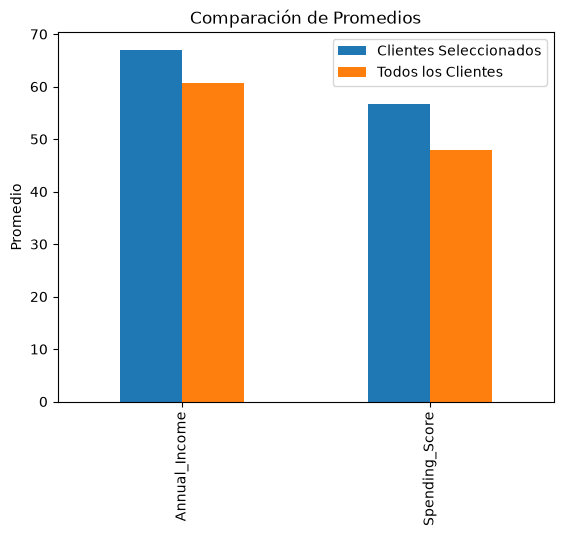

In [43]:
#podemos representar gráficamente la comparación de los promedios
import matplotlib.pyplot as plt
promedios = pd.DataFrame({
    'Clientes Seleccionados': clientes_seleccionados[['Annual_Income', 'Spending_Score']].mean(),
    'Todos los Clientes': data[['Annual_Income', 'Spending_Score']].mean()
})

promedios.plot(kind='bar')
plt.title('Comparación de Promedios')
plt.ylabel('Promedio')
plt.show()

**_Obtiene la edad promedio de clientes que tienen un sueldo mayor al promedio._**

In [45]:
#Obtiene la edad promedio de clientes que tienen un sueldo mayor al promedio
promedio_sueldo = data['Annual_Income'].mean()
edad_promedio_clientes_sueldo_alto = data[data['Annual_Income'] > promedio_sueldo]['Age'].mean()
print(edad_promedio_clientes_sueldo_alto)

39.4


In [46]:
#Obtiene la edad promedio de clientes que tienen un sueldo menor al promedio
promedio_sueldo = data['Annual_Income'].mean()
edad_promedio_clientes_sueldo_bajo = data[data['Annual_Income'] <= promedio_sueldo]['Age'].mean()
print(edad_promedio_clientes_sueldo_bajo)

39.91304347826087


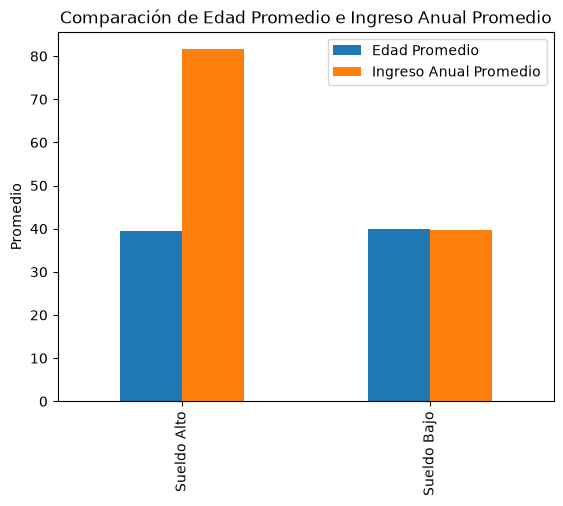

In [47]:
#realizamos un gráfico comparando la edad promedio de clientes con sueldo alto y bajo y los montos de ingresos anuales
import matplotlib.pyplot as plt

datos_comparacion = pd.DataFrame({
    'Edad Promedio': [edad_promedio_clientes_sueldo_alto, edad_promedio_clientes_sueldo_bajo],
    'Ingreso Anual Promedio': [data[data['Annual_Income'] > promedio_sueldo]['Annual_Income'].mean(),
                               data[data['Annual_Income'] <= promedio_sueldo]['Annual_Income'].mean()]
}, index=['Sueldo Alto', 'Sueldo Bajo'])

datos_comparacion.plot(kind='bar')
plt.title('Comparación de Edad Promedio e Ingreso Anual Promedio')
plt.ylabel('Promedio')
plt.show()

**_Compara estos valores con aquellos de los clientes en general._**

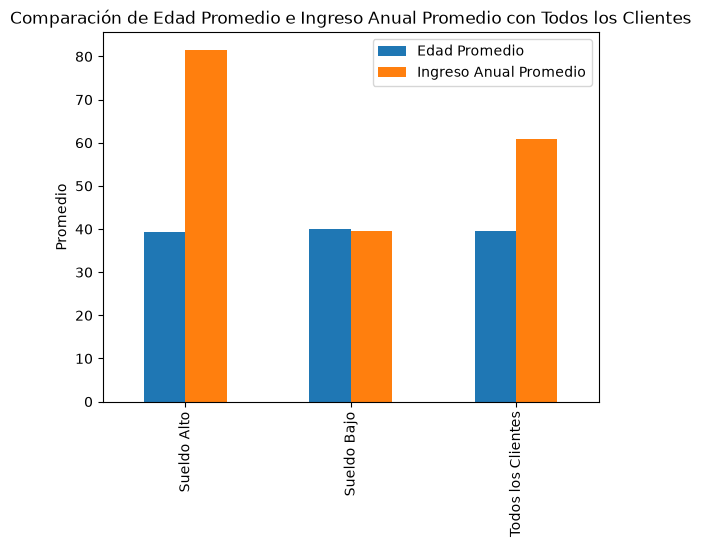

In [48]:
#comparamos los valores anteriores con la información de todos los clientes
datos_comparacion_todos = pd.DataFrame({
    'Edad Promedio': [edad_promedio_clientes_sueldo_alto, edad_promedio_clientes_sueldo_bajo, data['Age'].mean()],
    'Ingreso Anual Promedio': [data[data['Annual_Income'] > promedio_sueldo]['Annual_Income'].mean(),
                               data[data['Annual_Income'] <= promedio_sueldo]['Annual_Income'].mean(),
                               data['Annual_Income'].mean()]
}, index=['Sueldo Alto', 'Sueldo Bajo', 'Todos los Clientes'])

datos_comparacion_todos.plot(kind='bar')
plt.title('Comparación de Edad Promedio e Ingreso Anual Promedio con Todos los Clientes')
plt.ylabel('Promedio')
plt.show()

🤔 &nbsp; **_¿Qué otras preguntas te surgen para analizar en este dataset?_**

#### VISUALIZA LOS DATOS

**_Visualiza la distribución de las variables de sueldo promedio y puntaje de gastos. Haz gráficos que superpongan la distribución de cada una de estas variables de manera global como también sólo para los clientes seleccionados._**

C:\Users\gn_d4\AppData\Local\Temp\ipykernel_15584\823321350.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data['Annual_Income'], label='Ingreso Anual Global', shade=True)
C:\Users\gn_d4\AppData\Local\Temp\ipykernel_15584\823321350.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data['Spending_Score'], label='Puntaje de Gastos Global', shade=True)


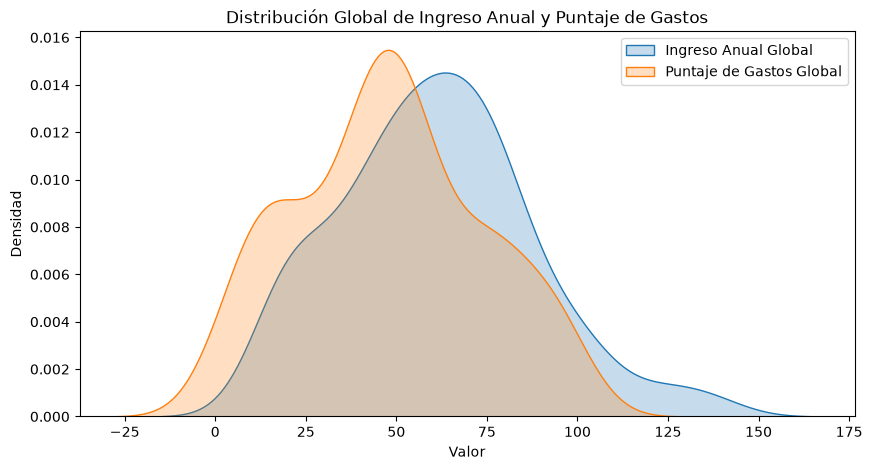

C:\Users\gn_d4\AppData\Local\Temp\ipykernel_15584\823321350.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(clientes_sueldo_alto['Annual_Income'], label='Ingreso Anual Sueldo Alto', shade=True)
C:\Users\gn_d4\AppData\Local\Temp\ipykernel_15584\823321350.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(clientes_sueldo_alto['Spending_Score'], label='Puntaje de Gastos Sueldo Alto', shade=True)


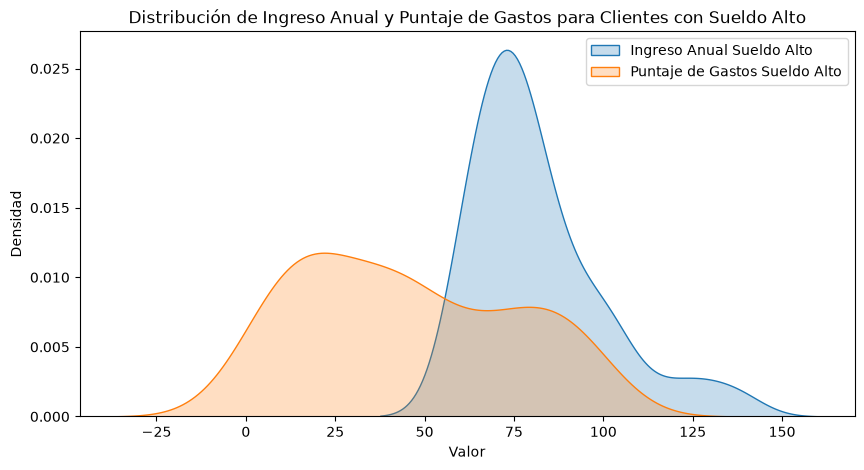

In [50]:
#Visualiza la distribución de las variables de sueldo promedio y puntaje de gastos. Haz gráficos que superpongan la distribución de cada una de estas variables de manera global como también sólo para los clientes seleccionados  
import seaborn as sns
import matplotlib.pyplot as plt

# Distribución global
plt.figure(figsize=(10, 5))
sns.kdeplot(data['Annual_Income'], label='Ingreso Anual Global', shade=True)
sns.kdeplot(data['Spending_Score'], label='Puntaje de Gastos Global', shade=True)
plt.title('Distribución Global de Ingreso Anual y Puntaje de Gastos')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# Distribución para clientes seleccionados (sueldo alto)
clientes_sueldo_alto = data[data['Annual_Income'] > promedio_sueldo]
plt.figure(figsize=(10, 5))
sns.kdeplot(clientes_sueldo_alto['Annual_Income'], label='Ingreso Anual Sueldo Alto', shade=True)
sns.kdeplot(clientes_sueldo_alto['Spending_Score'], label='Puntaje de Gastos Sueldo Alto', shade=True)
plt.title('Distribución de Ingreso Anual y Puntaje de Gastos para Clientes con Sueldo Alto')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.show()

**_Agrupa los datos por la variable `Genre` para ambos casos. Gráfica el ingreso promedio y su dispersion. Grafica, luego, el ingreso mediano y su rango intercuartil._**

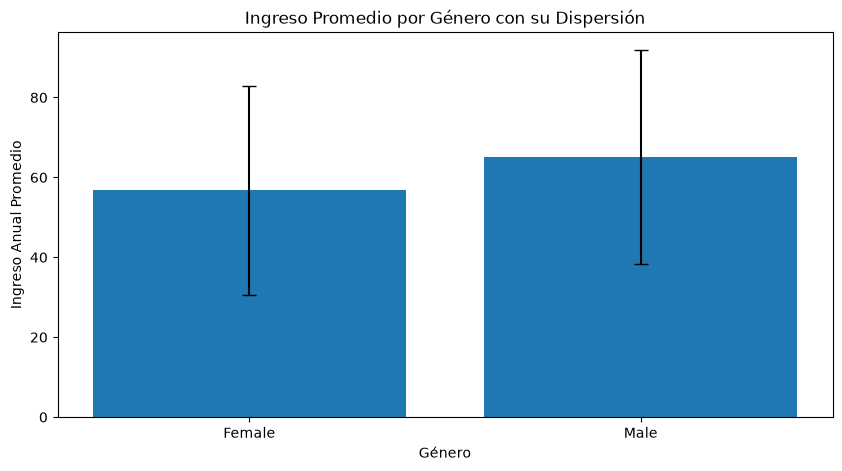

In [52]:
#Agrupa los datos por la variable `Genre` para ambos casos. Gráfica el ingreso promedio y su dispersion. Grafica, luego, el ingreso mediano y su rango intercuartil.  
import matplotlib.pyplot as plt
# Agrupamos los datos por 'Genre'
grouped_by_genre = data.groupby('Genre')
# Calculamos el ingreso promedio y su dispersión
income_mean = grouped_by_genre['Annual_Income'].mean()
income_std = grouped_by_genre['Annual_Income'].std()
# Graficamos el ingreso promedio con su dispersión
plt.figure(figsize=(10, 5))
plt.bar(income_mean.index, income_mean, yerr=income_std, capsize=5)
plt.title('Ingreso Promedio por Género con su Dispersión')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual Promedio')
plt.show()

🤔 &nbsp; **_¿Existe una correlación entre el sueldo anual y el puntaje de gastos en los clientes seleccionados? ¿Y en todos los clientes en general?_**

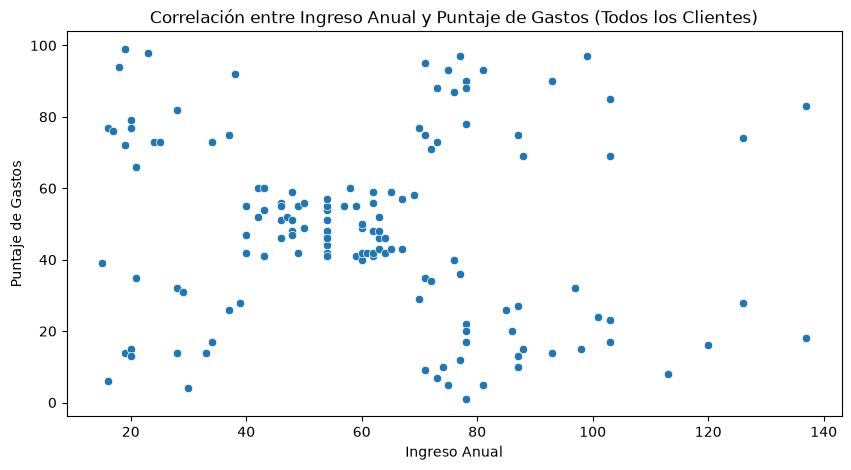

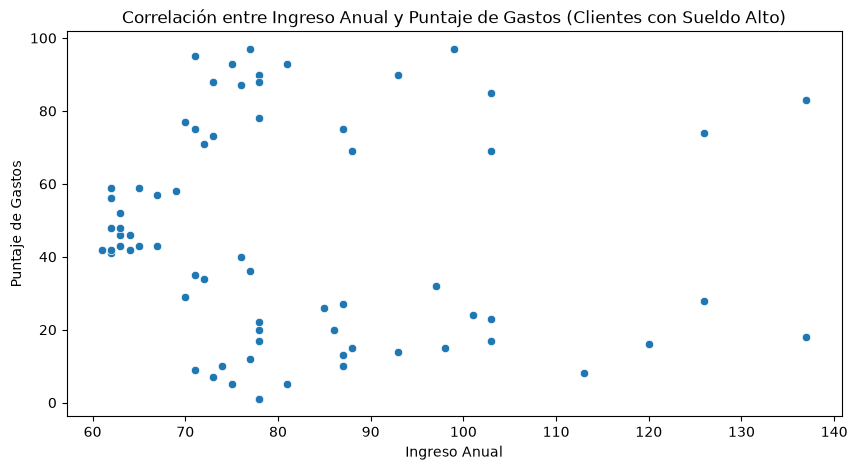

In [53]:
#¿Existe una correlación entre el sueldo anual y el puntaje de gastos en los clientes seleccionados? ¿Y en todos los clientes en general?
import seaborn as sns
import matplotlib.pyplot as plt

# Correlación en todos los clientes
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Annual_Income', y='Spending_Score', data=data)
plt.title('Correlación entre Ingreso Anual y Puntaje de Gastos (Todos los Clientes)')
plt.xlabel('Ingreso Anual')
plt.ylabel('Puntaje de Gastos')
plt.show()

# Correlación en clientes con sueldo alto
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Annual_Income', y='Spending_Score', data=clientes_sueldo_alto)
plt.title('Correlación entre Ingreso Anual y Puntaje de Gastos (Clientes con Sueldo Alto)')
plt.xlabel('Ingreso Anual')
plt.ylabel('Puntaje de Gastos')
plt.show()

**_Visualiza otros datos que creas relevantes para este analisis._**

#### 💾 &nbsp; GUARDANDO EL ARCHIVO PARA LOS SIGUIENTES PASOS

Los siguientes pasos que vamos a tomar implican la transformación de los datos presentes en el dataset para un correcto ajuste de un modelo a elección. Para no tener que correr nuevamente todo el código, podemos guardar en un archivo `csv` el dataset tal cual lo tenemos ahora.

1) **Utiliza la función `.to_csv()` para guardar tu dataset**. Antes de hacerlo chequea la [documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html).